# Regression

An analysis of the <span style ="color: #EB6800;">Astoria-Ditmars Blvd (N,W)</span> subway station with a multiple linear regression	

### Load ins 

In [1]:
setwd("/Users/Local/statsproject")

In [2]:
source("src/functions_and_things.r")

load_libraries()

nyc_blue   = "#0062CF"
nyc_orange = "#EB6800"

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ lubridate 1.9.4     ✔ tibble    3.3.0
✔ purrr     1.1.0     ✔ tidyr     1.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Please cite as: 


 Hlavac, Marek (2022). stargazer: Well-Formatted Regression and Summary Statistics Tables.

 R package version 5.2.3. https://CRAN.R-project.org/package=stargazer 


Warning message:
“package ‘zoo’ was built under R version 4.5.2”

Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric


Warning message:
“package ‘modelsummary’ was built under R version 4.5.2”
Warning message:
“package ‘fixest’ was built under R version

## Data

In [5]:
df <- read.csv("data/ignore/raw_hourly.csv")

df |> mutate(
        transit_timestamp= trimws(transit_timestamp),
        datetime         = mdy_hms(transit_timestamp),
        date             = as.Date(datetime),
        time             = format(datetime, "%H:%M:%S"),
        ridership        = as.numeric(ridership)) -> df

Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `ridership = as.numeric(ridership)`.
Caused by warning:
! NAs introduced by coercion”


In [7]:
head(df)

,X,transit_timestamp,station_complex,borough,ridership,datetime,date,time
,<int>,<chr>,<chr>,<chr>,<dbl>,<dttm>,<date>,<chr>
1,1,10/05/2024 09:00:00 PM,"Astoria-Ditmars Blvd (N,W)",Queens,86,2024-10-05 21:00:00,2024-10-05,21:00:00
2,2,12/07/2024 07:00:00 PM,"Astoria-Ditmars Blvd (N,W)",Queens,30,2024-12-07 19:00:00,2024-12-07,19:00:00
3,3,10/27/2024 04:00:00 PM,"Astoria-Ditmars Blvd (N,W)",Queens,32,2024-10-27 16:00:00,2024-10-27,16:00:00
4,4,11/17/2024 11:00:00 PM,"Astoria-Ditmars Blvd (N,W)",Queens,2,2024-11-17 23:00:00,2024-11-17,23:00:00
5,5,11/03/2024 07:00:00 PM,"Astoria-Ditmars Blvd (N,W)",Queens,8,2024-11-03 19:00:00,2024-11-03,19:00:00
6,6,10/12/2024 03:00:00 PM,"Astoria-Ditmars Blvd (N,W)",Queens,32,2024-10-12 15:00:00,2024-10-12,15:00:00


In [8]:
df|>select(ridership, date, borough) |>
    mutate(ridership = as.integer(ridership),
           day = weekdays(as.Date(date))) -> df_days 

In [9]:
head(df_days)

,ridership,date,borough,day
,<int>,<date>,<chr>,<chr>
1,86,2024-10-05,Queens,Saturday
2,30,2024-12-07,Queens,Saturday
3,32,2024-10-27,Queens,Sunday
4,2,2024-11-17,Queens,Sunday
5,8,2024-11-03,Queens,Sunday
6,32,2024-10-12,Queens,Saturday


In [13]:
# daily, including weekends and non rush hour

df_days |> 
    group_by(date, borough) |> 
    summarise(
        ridership = sum(ridership, na.rm = TRUE),
        .groups = "drop") |>
    mutate(day = weekdays(as.Date(date)),
           weekend = ifelse(day == "Saturday" | day == "Sunday", 1, 0)) |>
    select(date, borough, ridership, weekend) -> df

In [15]:
# weather data
weather_df <- read.csv("data/supplemental/weather.csv")

weather_df |> 
    rename(
        min_temp = TMIN, 
        snow     = SNOW,
        snow_d   = SNWD,
        rain     = PRCP) |> 
    mutate(date = as.Date(DATE), format = "%m-%d-%Y") |> 
    select(date, min_temp, snow, snow_d, rain) -> weather_df

head(weather_df)

,date,min_temp,snow,snow_d,rain
,<date>,<int>,<dbl>,<dbl>,<dbl>
1,2024-06-01,62,0,0,0.00
2,2024-06-02,62,0,0,0.00
3,2024-06-03,66,0,0,0.02
4,2024-06-04,64,0,0,0.00
5,2024-06-05,63,0,0,0.04
6,2024-06-06,69,0,0,0.58


In [16]:
head(df)
head(weather_df)

date,borough,ridership,weekend
<date>,<chr>,<int>,<dbl>
2024-06-01,Bronx,134258,1
2024-06-01,Brooklyn,512247,1
2024-06-01,Manhattan,950224,1
2024-06-01,Queens,340185,1
2024-06-02,Bronx,101863,1
2024-06-02,Brooklyn,410630,1


,date,min_temp,snow,snow_d,rain
,<date>,<int>,<dbl>,<dbl>,<dbl>
1,2024-06-01,62,0,0,0.00
2,2024-06-02,62,0,0,0.00
3,2024-06-03,66,0,0,0.02
4,2024-06-04,64,0,0,0.00
5,2024-06-05,63,0,0,0.04
6,2024-06-06,69,0,0,0.58


In [17]:
df |> left_join(weather_df, by = "date") -> df

head(df)

date,borough,ridership,weekend,min_temp,snow,snow_d,rain
<date>,<chr>,<int>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
2024-06-01,Bronx,134258,1,62,0,0,0
2024-06-01,Brooklyn,512247,1,62,0,0,0
2024-06-01,Manhattan,950224,1,62,0,0,0
2024-06-01,Queens,340185,1,62,0,0,0
2024-06-02,Bronx,101863,1,62,0,0,0
2024-06-02,Brooklyn,410630,1,62,0,0,0


In [18]:
dim(df)

[1] 2232    8

In [ ]:
colSums(is.na(df))

date   borough ridership   weekend  min_temp      snow    snow_d      rain 
        0         0         0         0         0         0        12         0

In [20]:
df |> 
    mutate(weekend = factor(weekend, labels = c("Weekday", "Weekend")),
           rain    = replace_na(rain, 0),
           rain_d  = rain > 0,
           temp    = as.numeric(min_temp),
           snow    = as.numeric(snow)) |>
    select(-min_temp) -> df

head(df)

date,borough,ridership,weekend,snow,snow_d,rain,rain_d,temp
<date>,<chr>,<int>,<fct>,<dbl>,<dbl>,<dbl>,<lgl>,<dbl>
2024-06-01,Bronx,134258,Weekend,0,0,0,FALSE,62
2024-06-01,Brooklyn,512247,Weekend,0,0,0,FALSE,62
2024-06-01,Manhattan,950224,Weekend,0,0,0,FALSE,62
2024-06-01,Queens,340185,Weekend,0,0,0,FALSE,62
2024-06-02,Bronx,101863,Weekend,0,0,0,FALSE,62
2024-06-02,Brooklyn,410630,Weekend,0,0,0,FALSE,62


In [21]:
summary(df)

      date              borough            ridership          weekend    
 Min.   :2024-06-01   Length:2232        Min.   :    868   Weekday:1592  
 1st Qu.:2024-10-18   Class :character   1st Qu.: 293216   Weekend: 640  
 Median :2025-03-06   Mode  :character   Median : 525922                 
 Mean   :2025-03-06                      Mean   : 628813                 
 3rd Qu.:2025-07-24                      3rd Qu.: 855556                 
 Max.   :2025-12-10                      Max.   :1539053                 
                                                                         
      snow             snow_d             rain           rain_d       
 Min.   :0.00000   Min.   :0.00000   Min.   :0.00000   Mode :logical  
 1st Qu.:0.00000   1st Qu.:0.00000   1st Qu.:0.00000   FALSE:1484     
 Median :0.00000   Median :0.00000   Median :0.00000   TRUE :748      
 Mean   :0.02151   Mean   :0.03712   Mean   :0.08935                  
 3rd Qu.:0.00000   3rd Qu.:0.00000   3rd Qu.:0.04000 

### Some plots

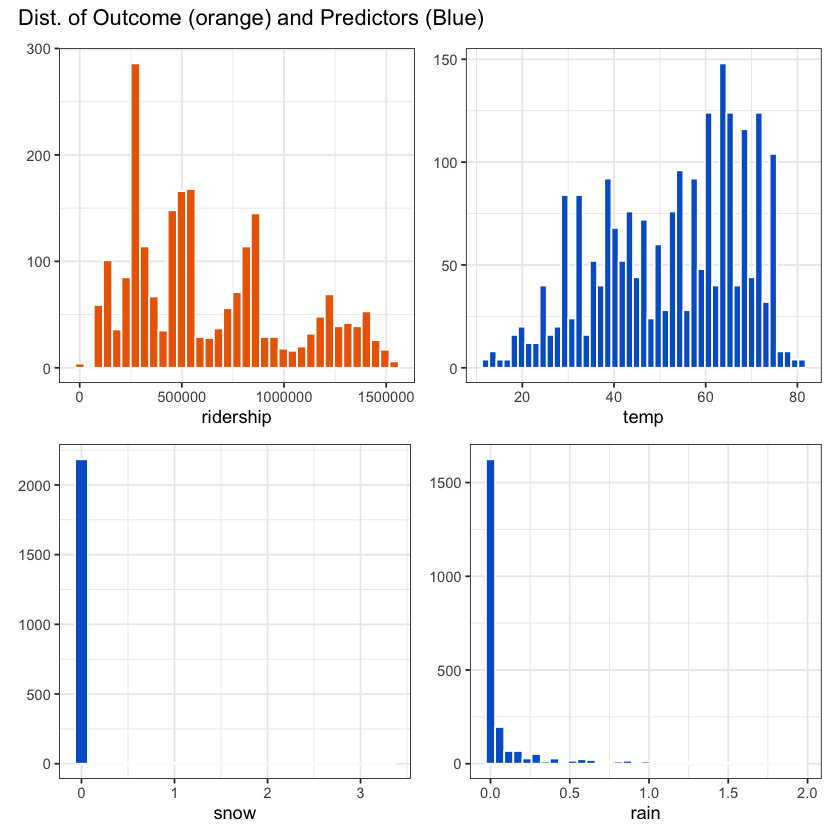

In [22]:
t <- theme_bw() + theme(axis.title.y = element_blank())
a <- ggplot(data = df, aes(x = ridership)) + 
        geom_histogram(bins = 35, color = "white", fill = nyc_orange) + t

b <- ggplot(data = df, aes(x = temp)) + 
        geom_histogram(bins = 45, color = "white", fill = nyc_blue) + t

c <- ggplot(data = df, aes(x = snow)) + 
        geom_histogram(bins = 25, color = "white", fill = nyc_blue) + t

d <- ggplot(data = df, aes(x = rain)) + 
        geom_histogram(bins = 35, color = "white", fill = nyc_blue) + t

(a + b )/ (c + d) + plot_annotation(title = "Dist. of Outcome (orange) and Predictors (Blue)")

In [23]:
df |> mutate(roll = rollmean(ridership, k= 7, fill = NA)) -> smooth

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 6 rows containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 6 rows containing missing values or values outside the scale range
(`geom_line()`).”


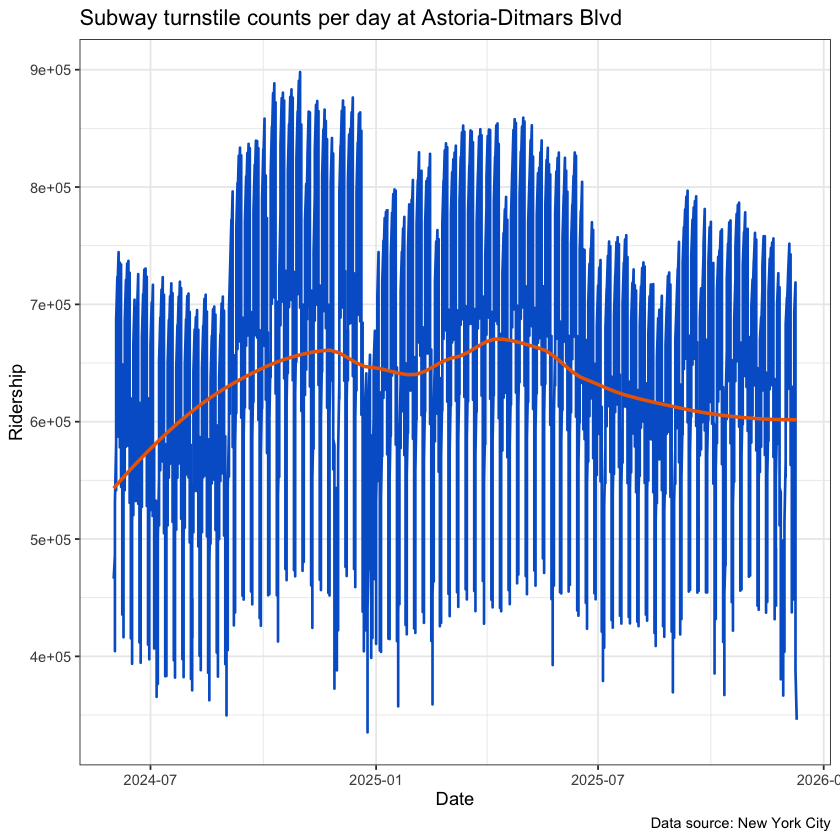

In [24]:
# ref 2 loess 

ggplot(data = smooth, aes(x = date, y = roll)) + 
    geom_line(col = nyc_blue, lwd = .75) + theme_bw() +
    geom_smooth(col = nyc_orange, method = "loess", span = .6, se=FALSE) + 
    labs(title = "Subway turnstile counts per day at Astoria-Ditmars Blvd",
         x     = "Date",
         y     = "Ridership",
         caption = "Data source: New York City")

`geom_smooth()` using formula = 'y ~ x'


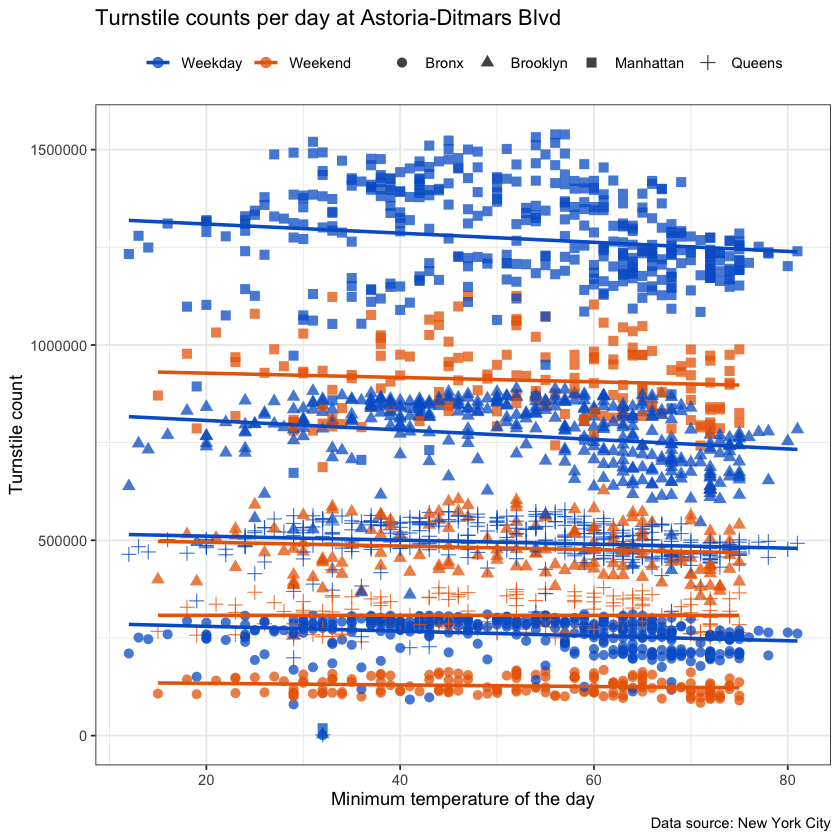

In [25]:
ggplot(data = df, aes(x = temp, y = ridership, color = weekend, shape = borough)) + 
    geom_point(size = 2.5, alpha = .75) + theme_bw() + 
    theme(legend.position = "top", legend.title = element_blank()) + 
    scale_color_manual(values = c("Weekend" = nyc_orange, "Weekday" = nyc_blue)) +
    geom_smooth(method = "lm", se = FALSE) + 
    labs(title = "Turnstile counts per day at Astoria-Ditmars Blvd",
         x     = "Minimum temperature of the day",
         y     = "Turnstile count",
         caption = "Data source: New York City")

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 1484 rows containing non-finite outside the scale range
(`stat_smooth()`).”


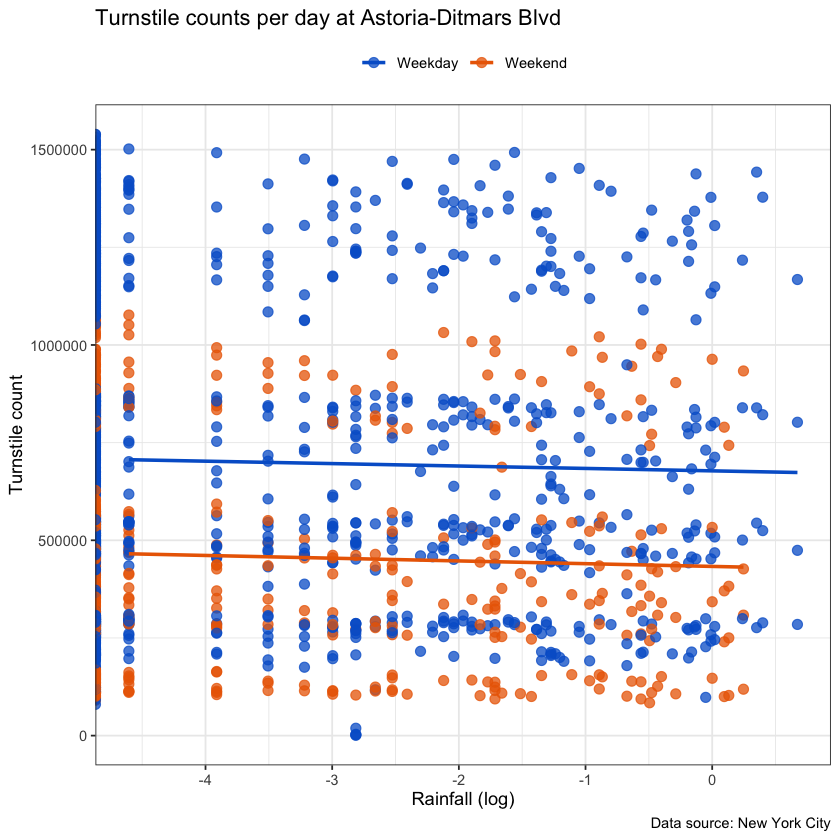

In [26]:
ggplot(data = df, aes(x = log(rain), y = ridership, color = weekend)) + 
    geom_point(size = 2.5, alpha = .75) + theme_bw() + 
    theme(legend.position = "top", legend.title = element_blank()) + 
    scale_color_manual(values = c("Weekend" = nyc_orange, "Weekday" = nyc_blue)) +
    geom_smooth(method = "lm", se = FALSE) + 
    labs(title = "Turnstile counts per day at Astoria-Ditmars Blvd",
         x     = "Rainfall (log)",
         y     = "Turnstile count",
         caption = "Data source: New York City")

`geom_smooth()` using formula = 'y ~ x'


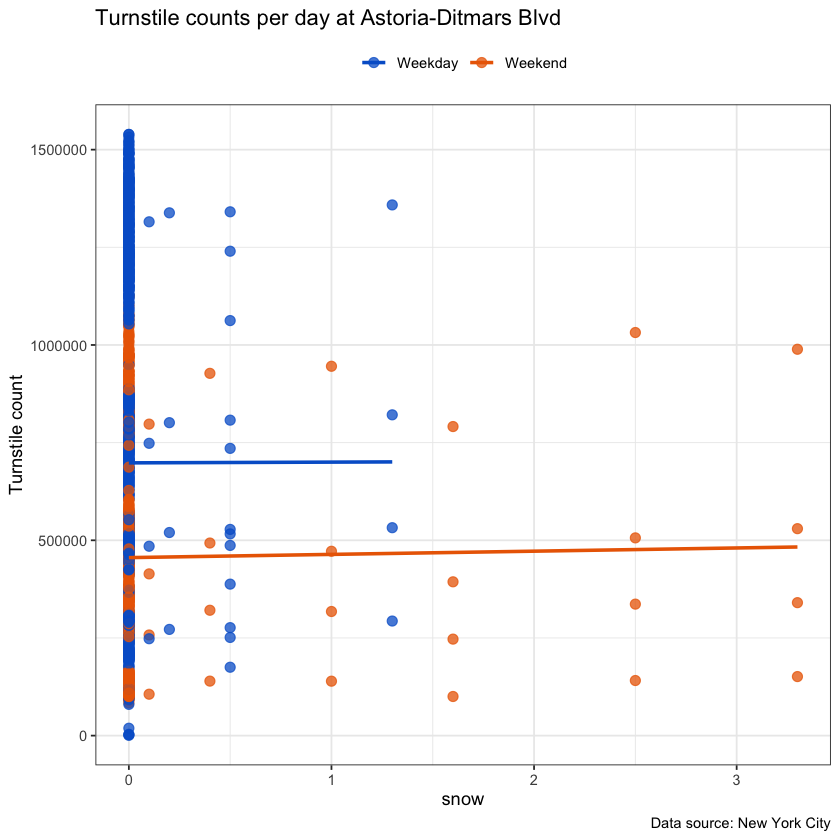

In [27]:
ggplot(data = df, aes(x = snow, y = ridership, color = weekend)) + 
    geom_point(size = 2.5, alpha = .75) + theme_bw() + 
    theme(legend.position = "top", legend.title = element_blank()) + 
    scale_color_manual(values = c("Weekend" = nyc_orange, "Weekday" = nyc_blue)) +
    geom_smooth(method = "lm", se = FALSE) + 
    labs(title = "Turnstile counts per day at Astoria-Ditmars Blvd",
         x     = "snow",
         y     = "Turnstile count",
         caption = "Data source: New York City")

### Regression

Full model 
**Model 1:** $Y_i = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \delta_1 x_3 + \epsilon_i $

**Model 1.5:** $Y_i = \beta_0 + \beta_1 x_1 + \beta_4 x_1^2 + \delta_1 x_2 + \delta_2 x_3 + \epsilon_i $

Reduced model
**Model 2:** $Y_i = \beta_0 + \beta_1 x_1 +\delta_1 x_3 + \epsilon_i $

Synergentic model
**Model 3:** $Y_i = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \delta_1 x_3 + \beta_4 (x_3 \times x_2) + \epsilon_i $

$$
\begin{align*}
&\text{where } \\
x_1 &= temperature \\
x_2 &= rain \text{(boolean)}\\
x_3 &= weekend \text{(boolean)} 
\end{align*}
$$

In [34]:
mod1 <- lm(ridership ~ temp  + weekend + rain_d, data = df)
mod15 <- lm(ridership ~ temp  + weekend + rain_d + I(temp^2), data = df)
mod2 <- lm(ridership ~ temp  + weekend + I(temp^2) + factor(borough), data = df)
mod3 <- lm(ridership ~ temp   + weekend + temp:weekend + rain_d + I(temp^2) + factor(borough), data = df)

stargazer(mod1, mod15, mod2, mod3, 
    style = "aer", type = "latex", out = "reg",
    title = "Astoria ridership regressions")


% Table created by stargazer v.5.2.3 by Marek Hlavac, Social Policy Institute. E-mail: marek.hlavac at gmail.com
% Date and time: Fri, Apr 24, 2026 - 04:15:03
\begin{table}[!htbp] \centering 
  \caption{Astoria ridership regressions} 
  \label{} 
\begin{tabular}{@{\extracolsep{5pt}}lcccc} 
\\[-1.8ex]\hline 
\hline \\[-1.8ex] 
\\[-1.8ex] & \multicolumn{4}{c}{ridership} \\ 
\\[-1.8ex] & (1) & (2) & (3) & (4)\\ 
\hline \\[-1.8ex] 
 temp & $-$694.049 & 7,662.618$^{**}$ & 7,597.892$^{***}$ & 7,498.474$^{***}$ \\ 
  & (496.756) & (3,199.986) & (843.851) & (848.580) \\ 
  & & & & \\ 
 weekendWeekend & $-$241,728.300$^{***}$ & $-$241,743.200$^{***}$ & $-$242,292.300$^{***}$ & $-$267,716.700$^{***}$ \\ 
  & (17,133.830) & (17,110.850) & (4,508.232) & (15,759.410) \\ 
  & & & & \\ 
 rain\_d & $-$8,807.306 & $-$9,768.538 &  & $-$9,387.935$^{**}$ \\ 
  & (16,465.920) & (16,447.860) &  & (4,339.660) \\ 
  & & & & \\ 
 I(temp$\hat{\mkern6mu}$2) &  & $-$84.620$^{***}$ & $-$84.200$^{***}$ & $-$84.409

### Diagnostics

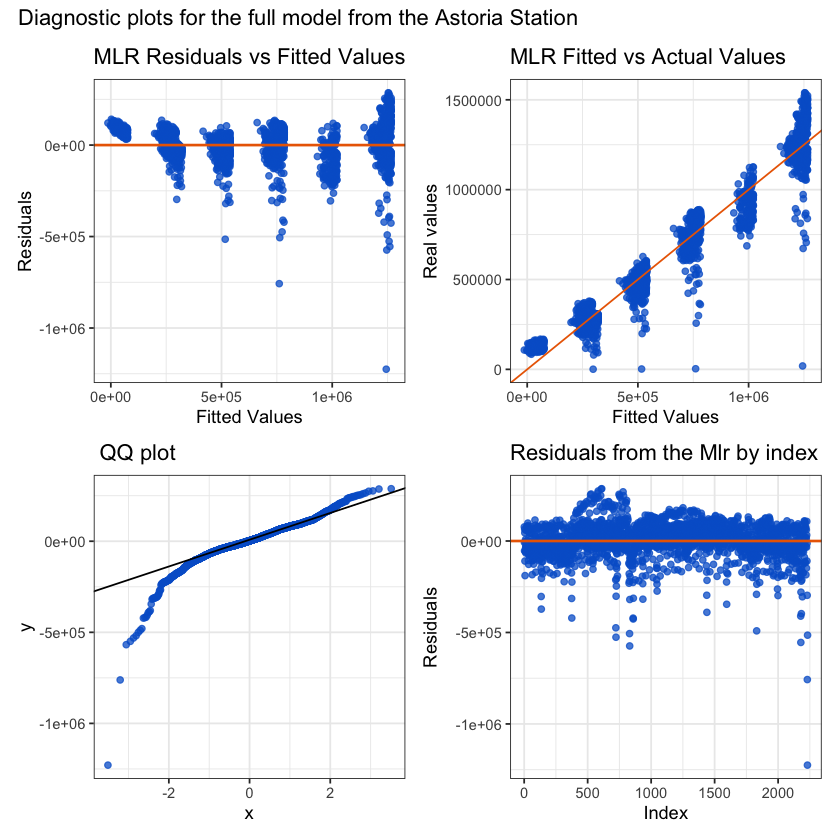

In [35]:
# from my hw5 submission 

mlr_fitted <- mod3$fitted 
mlr_resid <-  mod3$residuals 

df_resid <- data.frame(index = 1:nrow(df), mlr_resid,  mlr_fitted, 
                       real = df$ridership)

sand <- nyc_orange
sea  <- nyc_blue
sky <- "#87CEEB"

a <- ggplot(data = df_resid, aes()) + 
    geom_point(aes(y = mlr_resid, x = mlr_fitted), 
                    color = sea, alpha = .75) + 
    theme_bw() +
    labs(y = "Residuals", x = "Fitted Values", 
         title = "MLR Residuals vs Fitted Values") + 
    geom_hline(yintercept = 0, lwd = .75, col = sand)

# Actual vs not
b <- ggplot(data = df_resid, aes()) + 
    geom_point(aes(y = real, x = mlr_fitted),
                  color = sea, alpha = .75) + 
    theme_bw() +
    labs(y = "Real values", x = "Fitted Values", 
         title = "MLR Fitted vs Actual Values") + 
    geom_abline(intercept = 0, slope = 1, col = sand)

c <- ggplot(data.frame(res=residuals(mod2)), aes(sample=res)) +
     stat_qq(color = sea, alpha = .75) + theme_bw() + 
     stat_qq_line() + 
     labs(title = " QQ plot ")

d <-ggplot(data = df_resid, aes(x = index, y = mlr_resid)) + 
    geom_point(color = sea, alpha = .75) + theme_bw() +
    geom_hline(yintercept = 0, lwd = .75, col = sand) +
    labs(title = "Residuals from the Mlr by index",
             x = "Index",
             y = "Residuals")

a + b + c + d + plot_annotation(title = "Diagnostic plots for the full model from the Astoria Station")

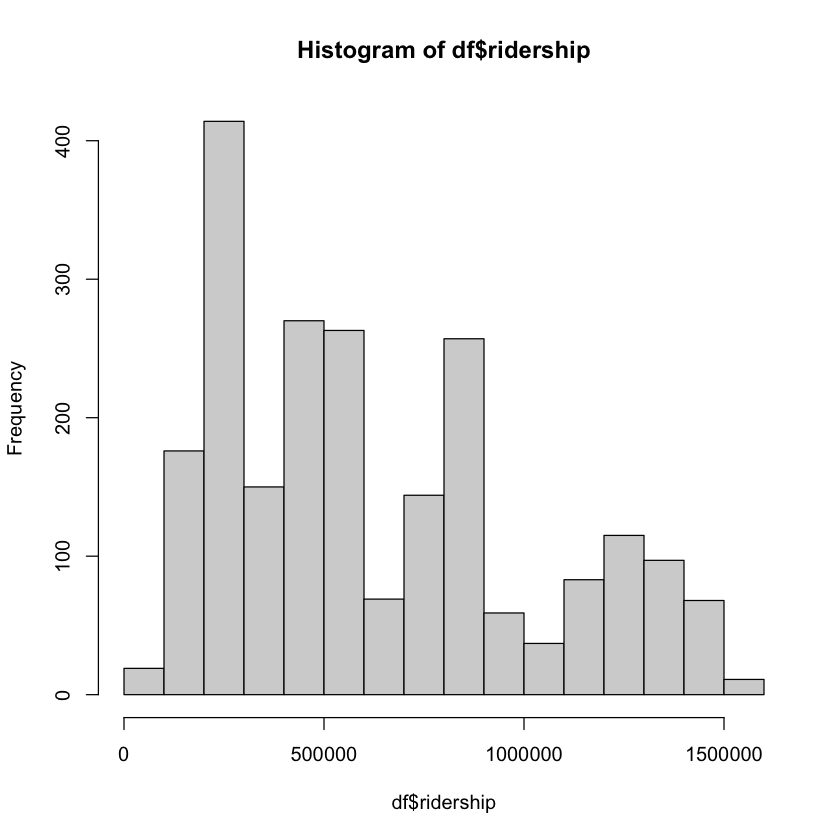

In [36]:
hist(df$ridership)

### lineararity 

* not unbiased 
* low explanatory power
* interences biased 


Call:
lm(formula = ridership_log ~ temp + weekend + temp:weekend + 
    rain_d + I(temp^2), data = df)

Residuals:
    Min      1Q  Median      3Q     Max 
-6.4798 -0.6447 -0.0116  0.4619  1.1410 

Coefficients:
                      Estimate Std. Error t value Pr(>|t|)    
(Intercept)          1.297e+01  1.439e-01  90.148  < 2e-16 ***
temp                 1.482e-02  6.012e-03   2.465   0.0138 *  
weekendWeekend      -4.543e-01  1.116e-01  -4.069 4.88e-05 ***
rain_dTRUE          -4.167e-02  3.074e-02  -1.355   0.1755    
I(temp^2)           -1.531e-04  5.976e-05  -2.562   0.0105 *  
temp:weekendWeekend -5.715e-04  2.044e-03  -0.280   0.7798    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.6814 on 2226 degrees of freedom
Multiple R-squared:  0.09775,	Adjusted R-squared:  0.09572 
F-statistic: 48.23 on 5 and 2226 DF,  p-value: < 2.2e-16


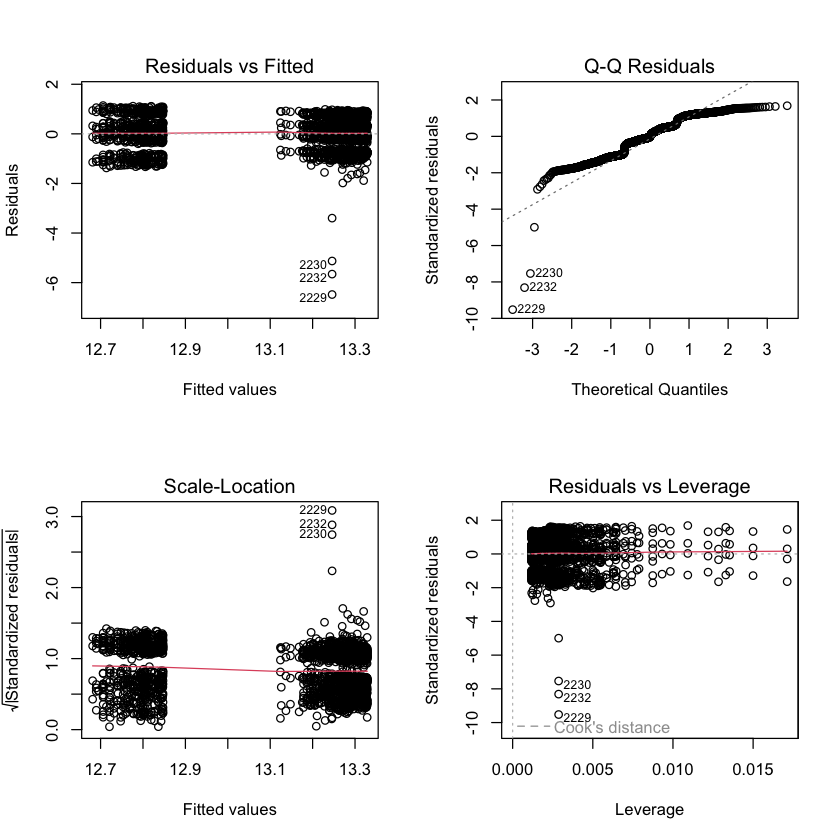

In [37]:
df$ridership_log <- log(df$ridership)

mod3_transform <- lm(ridership_log ~ temp   + weekend + temp:weekend + rain_d+ I(temp^2), data = df)
summary(mod3_transform)

par(mfrow = c(2,2))
plot(mod3_transform)

### independence

In [38]:
dwtest(mod3)


	Durbin-Watson test

data:  mod3
DW = 0.99115, p-value < 2.2e-16
alternative hypothesis: true autocorrelation is greater than 0


### normality

In [39]:
shapiro.test(df$ridership)
shapiro.test(mod3$residuals)


	Shapiro-Wilk normality test

data:  df$ridership
W = 0.92682, p-value < 2.2e-16



	Shapiro-Wilk normality test

data:  mod3$residuals
W = 0.89075, p-value < 2.2e-16


### Selection

In [40]:
anova(mod2, mod3)

,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2225,2.064252e+13,NA,NA,NA,NA
2,2223,2.056814e+13,2,74377010938,4.019325,0.01809581


#### train and test 

In [41]:
train <- train_test(df)$train
test <- train_test(df)$test

cat("There are", dim(train)[1], "rows and",dim(train)[2],"columns in the training set.\n")  #check the dimensions

cat("There are", dim(test)[1], "rows and",dim(test)[2],"columns in the testing set.")  #check the dimensions

There are 1785 rows and 10 columns in the training set.
There are 447 rows and 10 columns in the testing set.

In [42]:
mod1_train  <- lm(ridership ~ temp , data = train)
mod15_train <- lm(ridership ~ temp  + weekend + rain_d + I(temp^2), data = train)
mod2_train  <- lm(ridership ~ temp  + weekend, data = train)
mod3_train  <- lm(ridership ~ temp  + weekend + temp:weekend + rain_d+ I(temp^2), data = train)

In [43]:
stargazer(mod1_train, mod2_train, mod15_train, mod3_train, 
    style = "aer", type = "text", 
    title = "Astoria ridership regressions fit on training data")


Astoria ridership regressions fit on training data
                                                                ridership                                             
                              (1)                     (2)                      (3)                      (4)           
----------------------------------------------------------------------------------------------------------------------
temp                       -761.965                 -850.803               8,185.510**              7,969.877**       
                           (579.788)               (556.151)               (3,601.596)              (3,639.477)       
                                                                                                                      
weekendWeekend                                  -241,026.100***          -239,423.300***          -266,116.700***     
                                                  (19,291.650)             (19,288.780)             (66,956.750)   

In [44]:
#function made from code from cw 7

a <- eval("SLR", test, mod1_train)
b <- eval("With weekend", test, mod2_train)
c <- eval("Polynomial", test, mod15_train)
d <- eval("Full", test, mod3_train)

df_eval <- rbind(a, b, c, d)
df_eval

print(df_eval)

name,mspe,aic,bic
<chr>,<dbl>,<dbl>,<dbl>
SLR,141050055935,50964.27,50980.74
With weekend,128261297095,50816.39,50838.34
Polynomial,128443766089,50812.96,50845.88
Full,128433225227,50814.78,50853.20


          name         mspe      aic      bic
1          SLR 141050055935 50964.27 50980.74
2 With weekend 128261297095 50816.39 50838.34
3   Polynomial 128443766089 50812.96 50845.88
4         Full 128433225227 50814.78 50853.20


In [46]:
# cvode from midterm 2 practice exam 
n = dim(train)[1]

train |> select(ridership, temp, rain_d, weekend, borough) |>
      mutate(temp2 = temp^2) -> mod_eval

reg1  <- regsubsets(ridership ~ ., data = mod_eval)

summary(reg1)$which 

,(Intercept),temp,rain_dTRUE,weekendWeekend,boroughBrooklyn,boroughManhattan,boroughQueens,temp2
1,TRUE,FALSE,FALSE,FALSE,FALSE,TRUE,FALSE,FALSE
2,TRUE,FALSE,FALSE,FALSE,TRUE,TRUE,FALSE,FALSE
3,TRUE,FALSE,FALSE,TRUE,TRUE,TRUE,FALSE,FALSE
4,TRUE,FALSE,FALSE,TRUE,TRUE,TRUE,TRUE,FALSE
5,TRUE,FALSE,FALSE,TRUE,TRUE,TRUE,TRUE,TRUE
6,TRUE,TRUE,FALSE,TRUE,TRUE,TRUE,TRUE,TRUE
7,TRUE,TRUE,TRUE,TRUE,TRUE,TRUE,TRUE,TRUE
